Extraction des données réelles du marché pour NVDA...


/tmp/ipykernel_3373/2925454568.py:67: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="1y", group_by='column')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3373/2925454568.py:77: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(close_prices.iloc[-1])


Calibrage réussi -> Spot: $203.53 | Volatilité Historique Annualisée: 35.68%
📈 Analyse des Grecs sauvegardée avec succès dans 'plots/options_greeks_analysis.png'


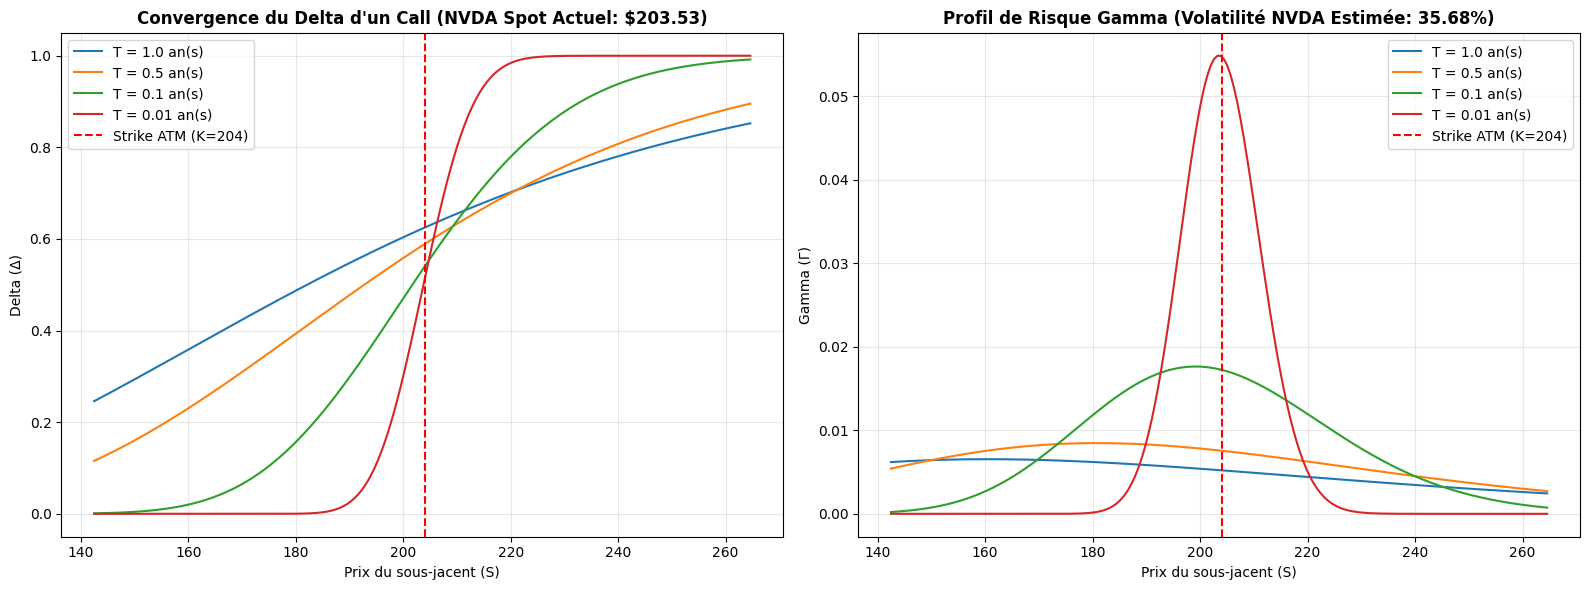

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm

# =====================================================================
# 1. MOTEUR ANALYTIQUE : BLACK-SCHOLES & LES 4 GRECS PRINCIPAUX
# =====================================================================

def bs_params(S, K, T, r, sigma):
    """Calcule d1 et d2 en protégeant le code contre la division par zéro si T -> 0."""
    T_safe = max(T, 1e-5)  # Évite la division par zéro à l'échéance exacte
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T_safe) / (sigma * np.sqrt(T_safe))
    d2 = d1 - sigma * np.sqrt(T_safe)
    return d1, d2

def bs_pricing_and_greeks(S, K, T, r, sigma, option_type="call"):
    """
    Calcule analytiquement le prix et les Grecs primaires (Delta, Gamma, Vega, Theta).
    Retourne un dictionnaire complet des métriques de sensibilité.
    """
    T_safe = max(T, 1e-5)
    d1, d2 = bs_params(S, K, T, r, sigma)

    # Distribution normale standard (N) et sa dérivée (N')
    N_d1 = norm.cdf(d1)
    N_d2 = norm.cdf(d2)
    n_prime_d1 = norm.pdf(d1) # Représente la densité de probabilité N'(d1)

    if option_type.lower() == "call":
        price = S * N_d1 - K * np.exp(-r * T_safe) * N_d2
        delta = N_d1
        theta = (- (S * n_prime_d1 * sigma) / (2 * np.sqrt(T_safe))
                 - r * K * np.exp(-r * T_safe) * N_d2)
    elif option_type.lower() == "put":
        price = K * np.exp(-r * T_safe) * norm.cdf(-d2) - S * norm.cdf(-d1)
        delta = N_d1 - 1
        theta = (- (S * n_prime_d1 * sigma) / (2 * np.sqrt(T_safe))
                 + r * K * np.exp(-r * T_safe) * norm.cdf(-d2))
    else:
        raise ValueError("option_type doit être 'call' ou 'put'")

    # Gamma et Vega sont identiques pour les Calls et les Puts
    gamma = n_prime_d1 / (S * sigma * np.sqrt(T_safe))
    vega = S * np.sqrt(T_safe) * n_prime_d1

    return {
        "price": price,
        "delta": delta,
        "gamma": gamma,
        "vega": vega / 100,         # Volatilité exprimée pour un mouvement de 1%
        "theta_daily": theta / 365   # Effet du temps exprimé par jour calendaire
    }

# =====================================================================
# 2. INGESTION DE DONNÉES ET PIPELINE DE CALIBRAGE MARCHÉ
# =====================================================================

def fetch_market_calibrated_data(ticker="NVDA"):
    """
    Télécharge les prix réels du marché, extrait le dernier cours spot
    et estime la volatilité historique annualisée.
    """
    print(f"Extraction des données réelles du marché pour {ticker}...")
    data = yf.download(ticker, period="1y", group_by='column')

    if 'Adj Close' in data.columns:
        close_prices = data['Adj Close']
    elif 'Close' in data.columns:
        close_prices = data['Close']
    else:
        close_prices = data.xs('Adj Close', axis=1, level=0) if 'Adj Close' in data.columns.levels[0] else data.xs('Close', axis=1, level=0)

    # Extraction du dernier cours Spot disponible
    S0 = float(close_prices.iloc[-1])

    # Calcul de la volatilité historique
    log_returns = np.log(close_prices / close_prices.shift(1)).dropna()
    annualized_vol = np.std(log_returns.values) * np.sqrt(252)

    return S0, float(annualized_vol)

# =====================================================================
# 3. GÉNERATION DES VISUALISATIONS DOUBLE-PANEL (PRODUCTION READY)
# =====================================================================

def generate_risk_profiles(S0, sigma, ticker="NVDA"):
    """Génère et sauvegarde l'analyse jointe du Delta et du Gamma risk."""
    K = round(S0)             # Le Strike s'aligne automatiquement At-The-Money (ATM)
    r = 0.05                  # Hypothèse de taux sans risque macro (5%)
    times_to_expiry = [1.0, 0.5, 0.1, 0.01]

    # Range dynamique : de -30% à +30% autour du prix spot actuel de NVDA
    S_range = np.linspace(S0 * 0.7, S0 * 1.3, 200)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    for T in times_to_expiry:
        deltas = []
        gammas = []
        for S in S_range:
            metrics = bs_pricing_and_greeks(S, K, T, r, sigma, option_type="call")
            deltas.append(metrics["delta"])
            gammas.append(metrics["gamma"])

        ax1.plot(S_range, deltas, label=f"T = {T} an(s)")
        ax2.plot(S_range, gammas, label=f"T = {T} an(s)")

    # Configuration Graphique 1 : Convergence du Delta
    ax1.axvline(x=K, color="red", linestyle="--", label=f"Strike ATM (K={K})")
    ax1.set_title(f"Convergence du Delta d'un Call ({ticker} Spot Actuel: ${S0:.2f})", fontweight='bold')
    ax1.set_xlabel("Prix du sous-jacent (S)")
    ax1.set_ylabel("Delta (Δ)")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Configuration Graphique 2 : Profil de Risque Gamma
    ax2.axvline(x=K, color="red", linestyle="--", label=f"Strike ATM (K={K})")
    ax2.set_title(f"Profil de Risque Gamma (Volatilité {ticker} Estimée: {sigma:.2%})", fontweight='bold')
    ax2.set_xlabel("Prix du sous-jacent (S)")
    ax2.set_ylabel("Gamma (Γ)")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()

    # Sauvegarde de la figure pour ton GitHub README
    os.makedirs("plots", exist_ok=True)
    plt.savefig("plots/options_greeks_analysis.png", dpi=300)
    print("📈 Analyse des Grecs sauvegardée avec succès dans 'plots/options_greeks_analysis.png'")
    plt.show()

# =====================================================================
# 4. POINT D'ENTRÉE DU SCRIPT
# =====================================================================
if __name__ == "__main__":
    ticker = "NVDA"
    try:
        S0, vol = fetch_market_calibrated_data(ticker)
        print(f"Calibrage réussi -> Spot: ${S0:.2f} | Volatilité Historique Annualisée: {vol:.2%}")
        generate_risk_profiles(S0, vol, ticker)
    except Exception as e:
        print(f"❌ Échec de la récupération des données réelles : {e}")
        print("Exécution en mode secours (Fallback) avec des paramètres théoriques.")
        generate_risk_profiles(135.0, 0.45, "NVDA_Theoretical")